# Getting PVAccess Traces into Bluesky (unfortunately, without shot_num)

## References
1. [Ophyd-Async Tutorials](https://blueskyproject.io/ophyd-async/main/tutorials.html#)
2. ChatGPT!

In [21]:
# electron_daq.py
# Written by ChatGPT with help from Scott Feister on 2026-06-18.
#
# Simple ophyd-async wrapper for one EPICS pvAccess NTNDArray trace.
#
# This reads:
#
#     ELECTRON-DAQ:trace
#
# which is an EPICS pvAccess NTNDArray containing a 1D ushort trace.

from typing import Annotated as A

import numpy as np

from ophyd_async.core import SignalR, StandardReadable
from ophyd_async.core import StandardReadableFormat as Format
from ophyd_async.epics.core import EpicsDevice, PvSuffix


class ElectronDaqTrace(StandardReadable, EpicsDevice):
    """Simple readable device for ELECTRON-DAQ:trace."""

    # This PV is an NTNDArray, not a plain waveform record.
    #
    # ophyd-async can unpack the NTNDArray value into a numpy array.
    # The pvget output says the array is ushort[], so the result should
    # usually come back as something like dtype uint16.
    trace: A[
        SignalR[np.ndarray],
        PvSuffix("trace"),
        Format.HINTED_SIGNAL,
    ]

    def __init__(self, name: str = "electron_daq") -> None:
        # The prefix ends at the colon.
        # PvSuffix("trace") makes the full PV:
        #
        #     pva://ELECTRON-DAQ:trace
        #
        super().__init__(prefix="pva://ELECTRON-DAQ:", name=name)

In [22]:
from bluesky import plan_stubs as bps
from bluesky import plans as bp
from bluesky.run_engine import RunEngine, autoawait_in_bluesky_event_loop
from ophyd_async.core import init_devices
import matplotlib.pyplot as plt

In [23]:
RE = RunEngine(call_returns_result=True)
autoawait_in_bluesky_event_loop()


with init_devices():
    electron_daq = ElectronDaqTrace()

<class 'numpy.ndarray'>
(100,)
uint16
[123 122 123 132 131 133 137 141 138 141]


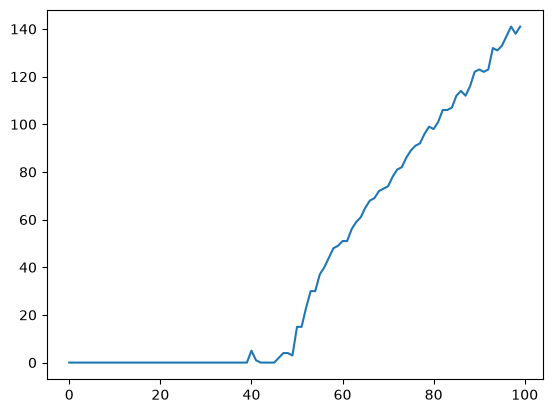

In [24]:
trace = await electron_daq.trace.get_value()

print(type(trace))
print(trace.shape)
print(trace.dtype)
print(trace[-10:])

plt.plot(trace)

In [25]:
RE(bps.rd(electron_daq.trace))

RunEngineResult(run_start_uids=(), plan_result=array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   1,   0,   0,   1,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   6,   9,  15,
        23,  27,  34,  39,  40,  44,  48,  49,  52,  53,  58,  58,  60,
        61,  58,  60,  69,  72,  75,  78,  85,  84,  84,  87,  85,  84,
        88,  98,  99,  98, 106, 111, 112, 110, 116, 118, 114, 121, 128,
       123, 128, 133, 135, 130, 138, 143, 141, 142], dtype=uint16), exit_status='success', interrupted=False, reason='', exception=None)

In [26]:
trace

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   5,   1,   0,   0,   0,   0,   2,   4,   4,   3,  15,  15,
        23,  30,  30,  37,  40,  44,  48,  49,  51,  51,  56,  59,  61,
        65,  68,  69,  72,  73,  74,  78,  81,  82,  86,  89,  91,  92,
        96,  99,  98, 101, 106, 106, 107, 112, 114, 112, 116, 122, 123,
       122, 123, 132, 131, 133, 137, 141, 138, 141], dtype=uint16)

In [27]:
type(trace)

numpy.ndarray

In [28]:
print(hasattr(trace, "timestamp"))

False
